# GPU

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Required Libraries

In [2]:
!pip install -q diffusers transformers accelerate safetensors

# Import LIbraries

In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


# Uplaod Stable diffusion

In [5]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Model loaded successfully!")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Model loaded successfully!


# Generate An Image

  0%|          | 0/50 [00:00<?, ?it/s]

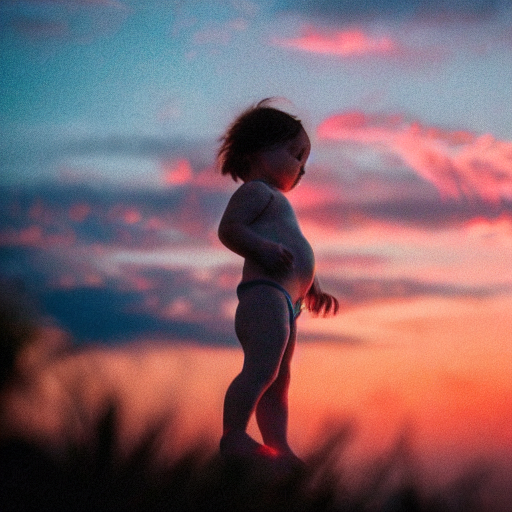

In [6]:
prompt = "A beautiful Baby girl at sunset, highly detailed, cinematic lighting"

image = pipe(prompt).images[0]

display(image)

# Image-to-Image

In [7]:
from diffusers import StableDiffusionImg2ImgPipeline

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

img2img_pipe = img2img_pipe.to("cuda")

print("Image-to-Image pipeline loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Image-to-Image pipeline loaded successfully!


# Sample Image

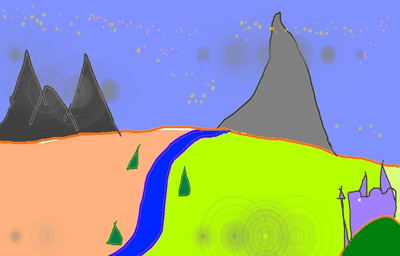

In [17]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((400, 256))
init_image

# Experiment

## Exp_With_Strength

In [18]:
init_image
img2img_pipe

StableDiffusionImg2ImgPipeline {
  "_class_name": "StableDiffusionImg2ImgPipeline",
  "_diffusers_version": "0.40.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/15 [00:00<?, ?it/s]

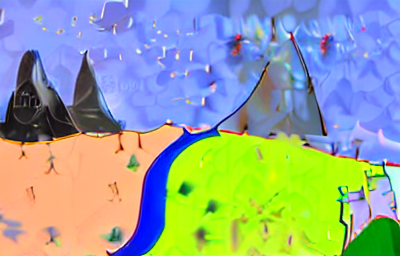

In [19]:
prompt = "A beautiful mountain landscape, snow-covered peaks, dramatic sky, highly detailed"

# Strength = 0.3
result_03 = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=0.3,
    guidance_scale=7.5
).images[0]

display(result_03)

  0%|          | 0/30 [00:00<?, ?it/s]

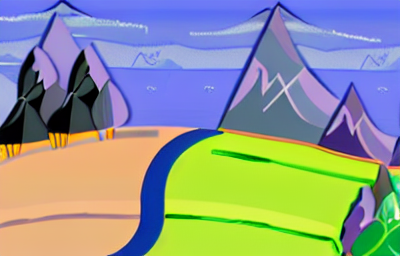

In [11]:
# Strength = 0.6
result_06 = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=0.6,
    guidance_scale=7.5
).images[0]

display(result_06)

  0%|          | 0/45 [00:00<?, ?it/s]

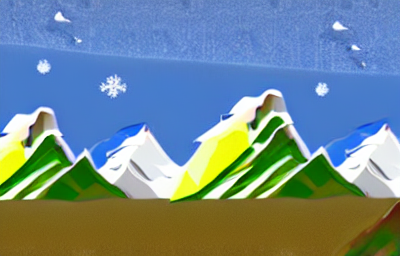

In [12]:
# Strength = 0.9
result_09 = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=0.9,
    guidance_scale=7.5
).images[0]

display(result_09)

# Reflection

This experiment demonstrated how the Strength parameter controls the balance between the original image and the generated result in an Image-to-Image diffusion model. With strength = 0.3, the original image was preserved more strongly, while strength = 0.6 produced a moderate level of modification. At strength = 0.9, the model made much more significant changes to the original image. Overall, I learned that lower strength values maintain more of the input image, whereas higher strength values allow the model to transform the image more dramatically.

# Upload InpaintPipeline

In [27]:
from diffusers import StableDiffusionInpaintPipeline
import torch

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_inpaint = pipe_inpaint.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Upload Image and Mask

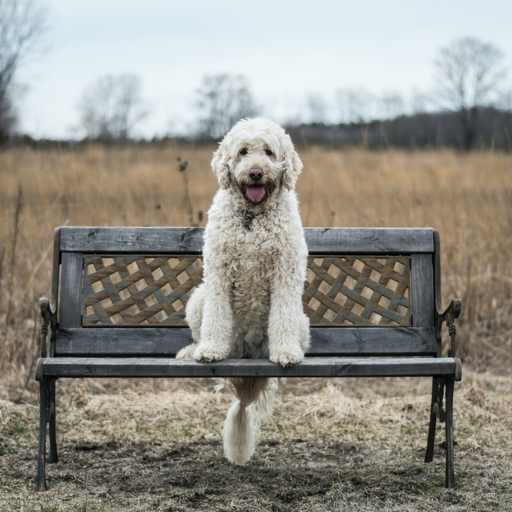

In [28]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"

mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

# Generate the mask region

  0%|          | 0/50 [00:00<?, ?it/s]

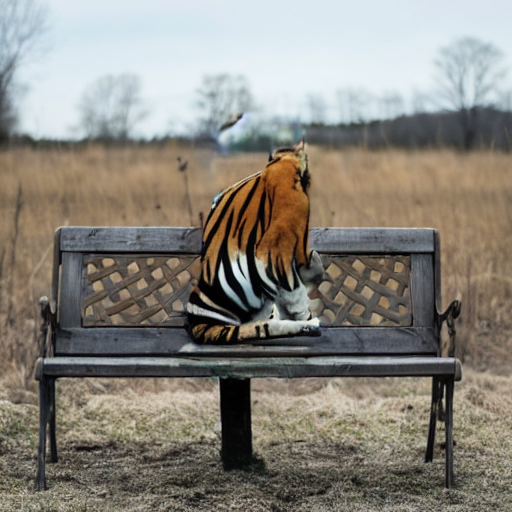

In [29]:
prompt = "a majestic tiger sitting on a bench"

result = pipe_inpaint(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image
).images[0]

display(result)

## • Does the edited region blend naturally with the rest of the image?

Answer:

The edited region can blend naturally with the rest of the image because the inpainting model uses the surrounding context to generate new content. However, the quality of blending may depend on the mask, prompt, lighting, colors, and the complexity of the original image.

## • What happens if you make the prompt vague vs. very specific?

Answer:

A vague prompt gives the model more freedom, which can produce unpredictable or less controlled results. A very specific prompt provides clearer instructions and usually generates content that better matches the desired object, appearance, and context.

# Control Net

## create canny edge map

In [34]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"

ref_image = load_image(url)

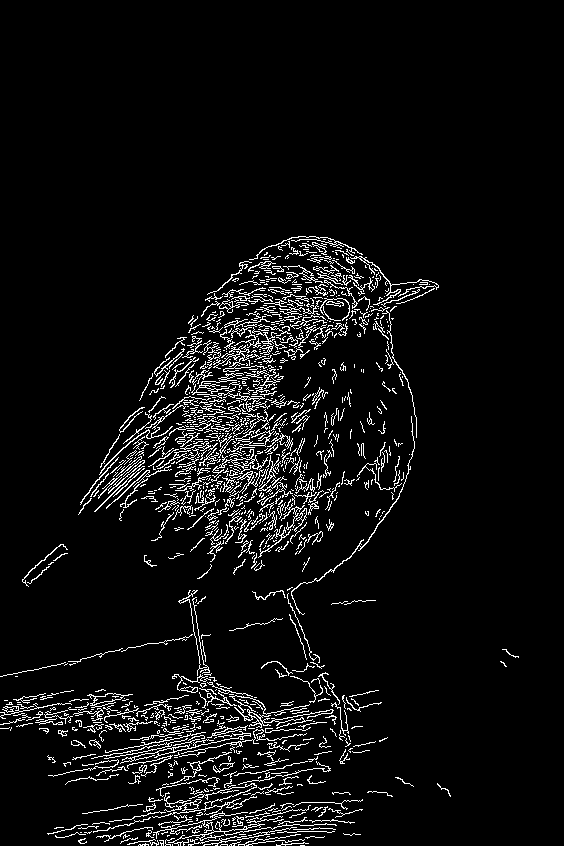

In [35]:
import cv2
import numpy as np
from PIL import Image

image = np.array(ref_image)

edges = cv2.Canny(image, 100, 200)

edges = np.stack([edges] * 3, axis=2)

canny_image = Image.fromarray(edges)

display(canny_image)

In [38]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

print("ControlNet pipeline loaded successfully!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

ControlNet pipeline loaded successfully!


In [40]:
import gc
import torch

# Previous pipelines delete karo
try:
    del pipe
except:
    pass

try:
    del img2img_pipe
except:
    pass

try:
    del pipe_inpaint
except:
    pass

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleaned!")

GPU memory cleaned!


## ControlNet optimization Enable

In [41]:
pipe_cn.enable_attention_slicing()

print("Memory optimization enabled!")

Memory optimization enabled!


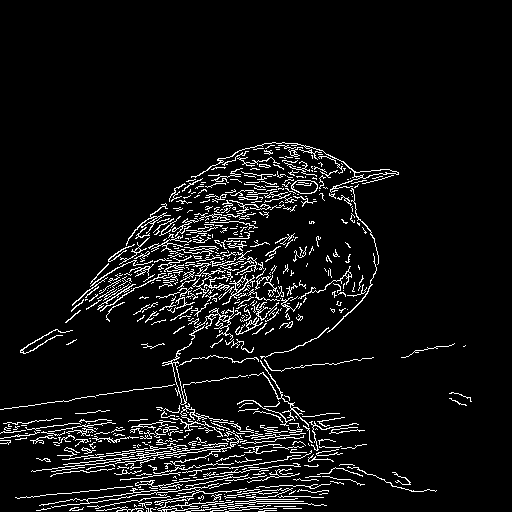

In [42]:
# image size reduce
ref_image = ref_image.resize((512, 512))

import numpy as np
import cv2
from PIL import Image

image = np.array(ref_image)

edges = cv2.Canny(image, 100, 200)

edges = np.stack([edges] * 3, axis=2)

canny_image = Image.fromarray(edges)

display(canny_image)

  0%|          | 0/20 [00:00<?, ?it/s]

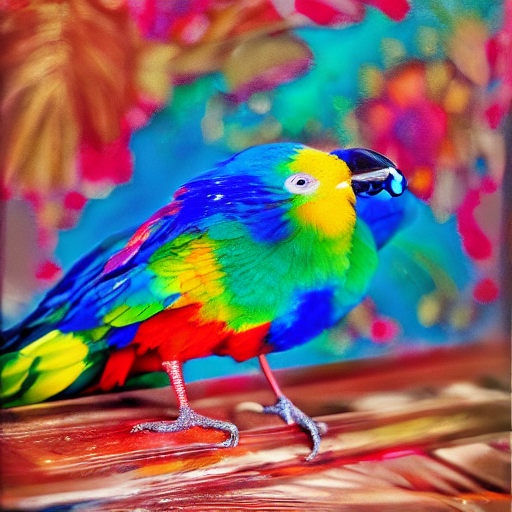

In [43]:
prompt = "a colorful parrot, highly detailed, studio lighting"

with torch.inference_mode():
    result = pipe_cn(
        prompt=prompt,
        image=canny_image,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]

display(result)

# Text=Exploration

In [44]:
# previous GPU memory
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleaned!")

GPU memory cleaned!


In [2]:
# import libraries
import torch

from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler
from diffusers.utils import export_to_video



In [3]:
# Load text to video model
pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)

pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe_video.scheduler.config
)

pipe_video.enable_model_cpu_offload()

print("Text-to-Video model loaded successfully!")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Text-to-Video model loaded successfully!


In [5]:
# import
pipe_video.enable_model_cpu_offload()

In [6]:
# Generate short video
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(
    prompt,
    num_inference_steps=25
).frames[0]

print("Video frames generated successfully!")

  0%|          | 0/25 [00:00<?, ?it/s]

Video frames generated successfully!


In [7]:
# fram into video
video_path = export_to_video(video_frames)

video_path

'/tmp/tmp99io4w7f.mp4'

In [8]:
# display video
from IPython.display import Video

Video(video_path, embed=True)

In [9]:
# download
from google.colab import files

files.download(video_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Discussion

## • How does video generation time compare to a single image?

Video generation takes significantly longer than generating a single image because a video consists of multiple frames. The model must generate and maintain visual information across all frames, which requires more computation and processing time. In comparison, generating a single image is faster because only one output needs to be created.


## • What inconsistencies or artifacts do you notice across frames?
Some inconsistencies can appear across video frames, such as changes in the shape or appearance of the subject, flickering, unstable backgrounds, distorted objects, or unnatural motion. In this example, the appearance of the golden retriever or parts of the beach and background may slightly change between frames. These artifacts occur because maintaining temporal consistency across multiple generated frames is more challenging than generating a single image.


## Compare reflection
When comparing the locally generated video with a hosted text-to-video demo using the same prompt, differences can be observed in quality, duration, and consistency. A hosted demo may produce smoother motion and better temporal consistency depending on the model and computational resources used. The local model can generate a short video successfully, but some visual artifacts or changes between frames may occur. Overall, text-to-video generation requires significantly more computational resources and time than text-to-image generation because the model must generate multiple visually consistent frames.
